<a href="https://colab.research.google.com/github/adaleidman/Data_Science_Project_AL/blob/main/DataCollectionAL_ProjectFinalCode_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Data Collection
# 1.1 Install libraries

!pip install yfinance pandas numpy

In [2]:
# 1.2 Import

import yfinance as yf
import pandas as pd
import numpy as np
import os

In [3]:
# 1.3 Download the S&P 500 data

end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=15)

df = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)

# flatten columns if needed, keep the five we want
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.rename(columns=str.title)[["Open", "High", "Low", "Close", "Volume"]]
df.index.name = "Date"

print("Downloaded", len(df), "rows, from", df.index.min().date(), "to", df.index.max().date())
df.head()

Downloaded 3770 rows, from 2011-07-15 to 2026-07-14


Price,Open,High,Low,Close,Volume
Date,,,,,
2011-07-15,1308.869995,1317.699951,1307.520020,1316.140015,4242760000
2011-07-18,1315.939941,1315.939941,1295.920044,1305.439941,4118160000
2011-07-19,1307.069946,1328.140015,1307.069946,1326.729980,4304600000
2011-07-20,1328.660034,1330.430054,1323.650024,1325.839966,3767420000
2011-07-21,1325.650024,1347.000000,1325.650024,1343.800049,4837430000


In [4]:
# 1.4 Save the raw data

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/sp500_raw.csv")
print("Saved data/raw/sp500_raw.csv")

Saved data/raw/sp500_raw.csv


In [5]:
# 1.5 Returns

df["return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

/tmp/ipykernel_561/4257459976.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["Close"].pct_change()


In [6]:
# 1.6 Moving averages (trend)

# Simple moving averages over 10, 20, 50 days — smooth the price to show the trend
for w in (10, 20, 50):
    df[f"sma_{w}"] = df["Close"].rolling(w).mean()

# Exponential moving averages weight recent days more; 12 & 26 are the MACD inputs
df["ema_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["ema_26"] = df["Close"].ewm(span=26, adjust=False).mean()


In [7]:
# 1.7 RSI (Relative Strength Index) (momentum)
# 1.7 RSI (Relative Strength Index) (momentum)

delta = df["Close"].diff()                                                       # daily price change (+ up days, - down days)
gain = delta.clip(lower=0)                                                       # keep gains only (losses -> 0)
loss = -delta.clip(upper=0)                                                      # keep losses only, as positive numbers
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()             # 14-day avg gain
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()             # 14-day avg loss

# RSI: scales the gain/loss ratio to 0-100 (high = overbought, low = oversold)
df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

In [8]:
# 1.8 MACD (Moving Average Convergence Divergence) (trend/momentum)

# MACD line: fast EMA minus slow EMA — positive = upward momentum
df["macd"] = df["ema_12"] - df["ema_26"]

# Signal line: 9-day smoothing of the MACD, used as a reference
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

# Histogram: gap between MACD and signal — shows if momentum is building or fading
df["macd_hist"] = df["macd"] - df["macd_signal"]

In [9]:
# 1.9 Bollinger Bands (volatility)

mid = df["Close"].rolling(20).mean()                                             # 20-day moving average (middle band)
std = df["Close"].rolling(20).std()                                              # 20-day volatility (standard deviation)
df["bb_upper"] = mid + 2 * std                                                   # upper band: 2 std above the average
df["bb_lower"] = mid - 2 * std                                                   # lower band: 2 std below the average

# band width relative to price — a single measure of how volatile the market is
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / mid

In [10]:
# 1.10 ATR (Average True Range) – how jumpy the market is – and 10-day momentum

prev_close = df["Close"].shift(1)                                                # yesterday's close
# True Range = the largest of: today's high-low range, and the gaps to yesterday's close
# (taking the max captures overnight jumps, not just the intraday range)

tr = pd.concat([df["High"] - df["Low"],
                (df["High"] - prev_close).abs(),
                (df["Low"] - prev_close).abs()], axis=1).max(axis=1)

# ATR: 14-day smoothed average of True Range — a measure of recent volatility
df["atr_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()

# Momentum: how far the price has moved over the last 10 days (+ rising, - falling)
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

In [11]:
# 1.10b External features: VIX (volatility) + 10-year Treasury yield (rates)
# drop first so this cell is safe to re-run (avoids "columns already exist" errors)
df = df.drop(columns=["vix", "yield_10y", "vix_change", "yield_change"],
             errors="ignore")

# download VIX (market fear gauge) and ^TNX (10-year Treasury yield) from Yahoo Finance
extra = yf.download(["^VIX", "^TNX"], start=start, end=end,
                    auto_adjust=True, progress=False)["Close"]
extra.columns = [str(c).replace("^", "") for c in extra.columns]                 # tidy column names
extra = extra.rename(columns={"VIX": "vix", "TNX": "yield_10y"})                 # rename to friendly labels

# safety check: make sure both columns actually downloaded before joining
assert {"vix", "yield_10y"}.issubset(extra.columns), extra.columns.tolist()

df = df.join(extra, how="left")                                                  # align the new features by date
df[["vix", "yield_10y"]] = df[["vix", "yield_10y"]].ffill()                      # forward-fill small gaps (past values only)

# check the join worked — 0 NaNs means every date matched up correctly
print("NaNs after ffill:", df[["vix", "yield_10y"]].isna().sum().to_dict())

df["vix_change"]   = df["vix"].pct_change()                                      # daily % change in market fear
df["yield_change"] = df["yield_10y"].diff()                                      # daily change in the interest rate

NaNs after ffill: {'vix': 0, 'yield_10y': 0}


In [12]:
# 1.11 GARCH

!pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.6 MB/s eta 0:00:00


In [13]:
# 1.11B

from arch import arch_model

r = (df["return"] * 100).dropna()
cut = int(len(r) * 0.8)
model = arch_model(r, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
res = model.fit(last_obs=r.index[cut], disp="off")

df["garch_vol"] = res.conditional_volatility / 100
df["garch_vol"] = df["garch_vol"].ffill()
print("Added GARCH volatility feature.")
print(df["garch_vol"].describe())

Added GARCH volatility feature.
count    3769.000000
mean        0.009089
std         0.005319
min         0.004328
25%         0.006601
50%         0.007014
75%         0.010362
max         0.077523
Name: garch_vol, dtype: float64


In [14]:
# 1.12 The prediction targets

df["next_return"] = df["Close"].pct_change().shift(-1)          # tomorrow's return
df["target_up"] = (df["Close"].shift(-1) > df["Close"]).astype(int)  # 1 = up, 0 = down

/tmp/ipykernel_561/2578699941.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["next_return"] = df["Close"].pct_change().shift(-1)          # tomorrow's return


In [15]:
# 1.13 Clean up and check

df = df.dropna()   # remove warm-up rows and the last row (no future target)
print("Final shape:", df.shape)
print("Up days:", round(df["target_up"].mean() * 100, 1), "%")
df.head()

Final shape: (3720, 28)
Up days: 54.5 %


,Open,High,Low,Close,Volume,return,log_return,sma_10,sma_20,sma_50,...,bb_width,atr_14,momentum_10,yield_10y,vix,vix_change,yield_change,garch_vol,next_return,target_up
Date,,,,,,,,,,,,,,,,,,,,,
2011-09-23,1128.819946,1141.719971,1121.359985,1136.430054,5639930000,0.006082,0.006064,1178.787012,1184.447009,1213.249204,...,0.089291,30.158633,-17.799927,1.808,41.250000,-0.002418,0.093,0.020865,0.023336,1
2011-09-26,1136.910034,1164.189941,1131.069946,1162.949951,4762830000,0.023336,0.023068,1178.855005,1183.754504,1210.185403,...,0.090659,30.370159,0.679932,1.904,39.020000,-0.054061,0.096,0.018681,0.010688,1
2011-09-27,1163.319946,1195.859985,1163.319946,1175.380005,5548130000,0.010688,0.010632,1179.106006,1182.019507,1207.584204,...,0.088496,30.551579,2.510010,2.016,37.709999,-0.033573,0.112,0.019300,-0.020691,0
2011-09-28,1175.390015,1184.709961,1150.400024,1151.060059,4787920000,-0.020691,-0.020908,1175.344006,1178.926508,1204.070806,...,0.088085,30.820033,-37.619995,2.002,41.080002,0.089366,-0.014,0.017695,0.008114,1
2011-09-29,1151.739990,1175.869995,1139.930054,1160.400024,5285740000,0.008114,0.008081,1170.473010,1176.002008,1200.762007,...,0.083246,31.185741,-48.709961,1.957,38.840000,-0.054528,-0.045,0.018342,-0.024974,0


In [16]:
# Save the finished dataset

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/sp500_features.csv")
print("Saved data/processed/sp500_features.csv")

Saved data/processed/sp500_features.csv


In [17]:
# 2. Descriptive Statistics

import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
# 2.1 Descriptive statistics table

desc = df.describe().T          # count, mean, std, min, quartiles, max
desc.to_csv("eda_describe.csv")  # saved for your report
desc.round(3)

,count,mean,std,min,25%,50%,75%,max
Open,3720.0,3.293601e+03,1.590632e+03,1097.420,2.044337e+03,2.817910e+03,4.336482e+03,7.605310e+03
High,3720.0,3.310936e+03,1.598650e+03,1125.120,2.055827e+03,2.835685e+03,4.365815e+03,7.620900e+03
Low,3720.0,3.275113e+03,1.581974e+03,1074.770,2.034767e+03,2.801505e+03,4.303972e+03,7.582990e+03
Close,3720.0,3.294363e+03,1.590924e+03,1099.230,2.044105e+03,2.818640e+03,4.337812e+03,7.609780e+03
Volume,3720.0,4.027223e+09,1.017680e+09,0.000,3.380492e+09,3.810315e+09,4.465778e+09,1.002582e+10
return,3720.0,1.000000e-03,1.100000e-02,-0.120,-4.000000e-03,1.000000e-03,6.000000e-03,9.500000e-02
log_return,3720.0,1.000000e-03,1.100000e-02,-0.128,-4.000000e-03,1.000000e-03,6.000000e-03,9.100000e-02
sma_10,3720.0,3.286691e+03,1.585137e+03,1141.441,2.042980e+03,2.817306e+03,4.333012e+03,7.545009e+03
sma_20,3720.0,3.278269e+03,1.578997e+03,1162.775,2.045002e+03,2.807123e+03,4.324616e+03,7.486618e+03
sma_50,3720.0,3.253012e+03,1.560055e+03,1172.023,2.026526e+03,2.798455e+03,4.336473e+03,7.440711e+03


In [19]:
# 2.2 Data quality + class balance

print("Missing values in total:", df.isna().sum().sum())   # should be 0
print("Trading days:", len(df))
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Up days: {:.1f}%   Down days: {:.1f}%".format(
      df['target_up'].mean()*100, (1 - df['target_up'].mean())*100))

Missing values in total: 0
Trading days: 3720
Date range: 2011-09-23 to 2026-07-13
Up days: 54.5%   Down days: 45.5%


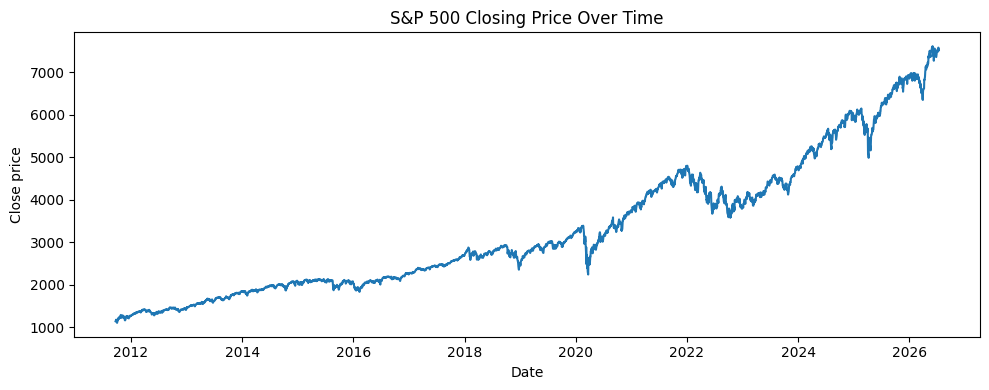

In [20]:
# 2.3 Closing price over time (shows the upward trend / non-stationarity)

plt.figure(figsize=(10,4))
plt.plot(df.index, df['Close'])
plt.title("S&P 500 Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Close price")
plt.tight_layout()
plt.savefig("eda_price.png", dpi=150)
plt.show()

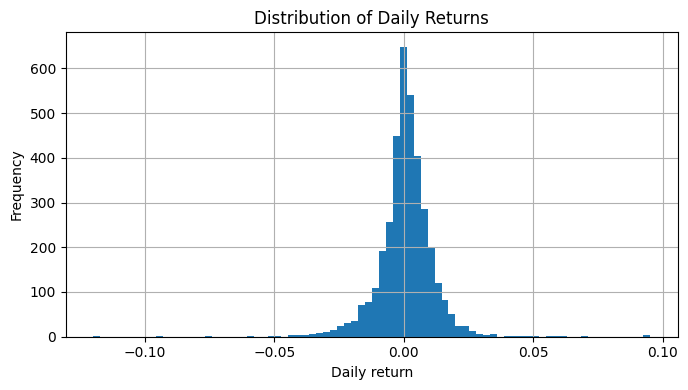

In [21]:
# 2.4 Distribution of daily returns

plt.figure(figsize=(7,4))
df['return'].hist(bins=80)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily return"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_returns.png", dpi=150)
plt.show()

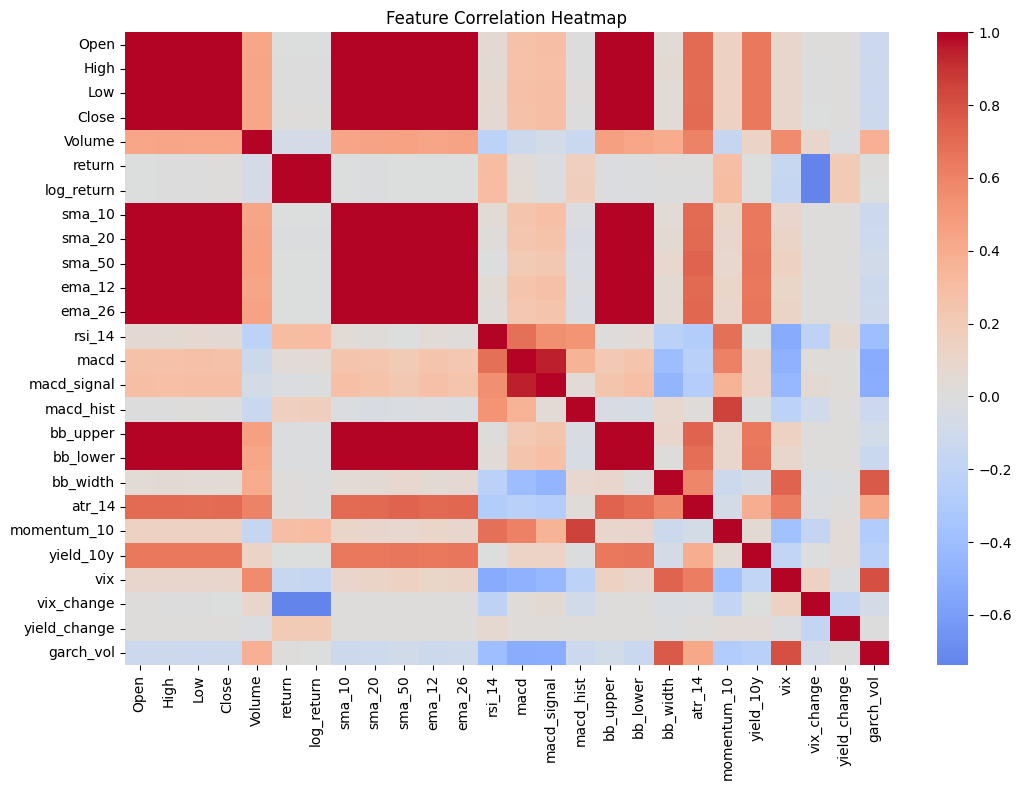

In [22]:
# 2.5 Feature correlation heatmap (key for your RQ3 — shows the indicators are correlated)

plt.figure(figsize=(11,8))
sns.heatmap(df.drop(columns=['target_up','next_return']).corr(),
            cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_corr.png", dpi=150)
plt.show()

In [23]:
# Download the outputs to keep them

from google.colab import files
for f in ["eda_describe.csv", "eda_price.png", "eda_returns.png", "eda_corr.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# 3. Modelling and Tunning

!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00


In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_row(name, y_true, y_pred):
    return {"model": name,
            "accuracy":  round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
            "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4)}

In [26]:
# 3.1 Features and target

DROP_COLS = ["target_up", "next_return"]                                         # not model inputs
feature_cols = [c for c in df.columns if c not in DROP_COLS]                     # everything else = the features
X = df[feature_cols].astype("float32")                                           # X = the 26 input features the model learns from
y = df["target_up"].astype("int").values                                         # y = the label: 1 = up tomorrow, 0 = down
print("Features:", len(feature_cols), "| samples:", len(X))                      # confirms 26 features, 3722 rows

Features: 26 | samples: 3720


In [27]:
# 3.1b Shock-smoothing (winsorize extreme return/macro days, train-bounds only)
cut = int(len(X) * 0.8)
shock_cols = [c for c in ["return", "log_return", "vix_change", "yield_change"]
              if c in X.columns]
lower = X[shock_cols].iloc[:cut].quantile(0.01)
upper = X[shock_cols].iloc[:cut].quantile(0.99)
X[shock_cols] = X[shock_cols].clip(lower=lower, upper=upper, axis=1)
print("Smoothed shocks — winsorized:", shock_cols)

Smoothed shocks — winsorized: ['return', 'log_return', 'vix_change', 'yield_change']


In [28]:
# 3.2 Chronological split + scaling (no leakage)

TEST_FRACTION = 0.20
cut = int(len(X) * (1 - TEST_FRACTION))                                          # split point: first 80% train, last 20% test
X_train, X_test = X.iloc[:cut], X.iloc[cut:]                                     # train = the PAST, test = the most RECENT period
y_train, y_test = y[:cut], y[cut:]                                               # never shuffled — time order is preserved

scaler = StandardScaler().fit(X_train)                                           # fit on TRAIN ONLY (no test info leaks in)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", len(X_train), " Test:", len(X_test))

results = []                                                                     # we collect each model's score here

Train: 2976  Test: 744


In [29]:
# 3.3 Naive baseline (the score to beat: ~57%)

majority = int(round(y_train.mean()))
naive_pred = np.full_like(y_test, majority)
results.append(metrics_row("Naive (majority)", y_test, naive_pred))
results[-1]

{'model': 'Naive (majority)',
 'accuracy': 0.5632,
 'precision': 0.5632,
 'recall': 1.0,
 'f1': 0.7206}

In [30]:
# 3.3b ARIMA baseline (classical statistical time-series model)
# ARIMA predicts the PRICE; we convert its forecast to an up/down direction to compare fairly.
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")                 # silence ARIMA convergence warnings

# use the closing price, aligned to the same chronological train/test split as every other model
close = df["Close"].reset_index(drop=True)
close_train = close.iloc[:cut]
close_test  = close.iloc[cut:]

# walk-forward one-step forecasts: refit on all data up to each test day, predict the next day
history = list(close_train)
arima_dir = []                                     # predicted direction: 1 = up, 0 = down
for actual in close_test:
    model = ARIMA(history, order=(5, 1, 0))        # ARIMA(5,1,0): 5 lags, 1 difference - a standard setup
    fit = model.fit()
    forecast = fit.forecast()[0]                   # predict tomorrow's price
    arima_dir.append(int(forecast > history[-1]))  # up if forecast is higher than today's close
    history.append(actual)                         # add the true value, then move one day forward

arima_pred = np.array(arima_dir)                   # one direction prediction per test day
results.append(metrics_row("ARIMA (5,1,0)", y_test, arima_pred))
results[-1]

{'model': 'ARIMA (5,1,0)',
 'accuracy': 0.4758,
 'precision': 0.5428,
 'recall': 0.4391,
 'f1': 0.4855}

In [ ]:
# 3.4 Random Forest, tuned with TimeSeriesSplit

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=TimeSeriesSplit(n_splits=5),
    scoring="accuracy", n_jobs=-1, verbose=1)
rf_search.fit(X_train_s, y_train)
print("Best RF params:", rf_search.best_params_)

rf_pred = rf_search.best_estimator_.predict(X_test_s)
results.append(metrics_row("Random Forest (tuned)", y_test, rf_pred))
results[-1]

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [32]:
# 3.5 Build sequences for the LSTM/GRU (with a chronological validation split)

LOOKBACK = 30
VAL_FRACTION = 0.20

def make_sequences(X2d, y1d, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X2d)):
        Xs.append(X2d[i-lookback:i]); ys.append(y1d[i])
    return np.array(Xs), np.array(ys)

vcut = int(len(X_train_s) * (1 - VAL_FRACTION))                                  # validation = last part of TRAIN
Xtr_seq, ytr_seq   = make_sequences(X_train_s[:vcut], y_train[:vcut])
Xval_seq, yval_seq = make_sequences(X_train_s[vcut:], y_train[vcut:])
Xte_seq,  yte_seq  = make_sequences(X_test_s, y_test)
n_features = X_train_s.shape[1]
print("Train seq:", Xtr_seq.shape, "| Val:", Xval_seq.shape, "| Test:", Xte_seq.shape)

Train seq: (2350, 30, 26) | Val: (566, 30, 26) | Test: (714, 30, 26)


In [33]:
# 3.6 Define the model for the tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([keras.Input(shape=(LOOKBACK, n_features))])
    rnn = layers.LSTM if hp.Choice("rnn", ["lstm", "gru"]) == "lstm" else layers.GRU
    n_layers = hp.Int("n_layers", 1, 2)
    units    = hp.Choice("units", [32, 64, 128])
    dropout  = hp.Float("dropout", 0.1, 0.4, step=0.1)
    lr       = hp.Choice("lr", [1e-3, 5e-4, 1e-4])
    for i in range(n_layers):
        model.add(rnn(units, return_sequences=(i < n_layers - 1)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [ ]:
# 3.7 Run the search (this is the slow part)

tuner = kt.Hyperband(build_model, objective="val_accuracy", max_epochs=30,
                     factor=3, directory="kt_dir", project_name="rnn_sp500",
                     overwrite=True)
stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                     restore_best_weights=True)
tuner.search(Xtr_seq, ytr_seq, validation_data=(Xval_seq, yval_seq),
             epochs=30, batch_size=32, callbacks=[stop], verbose=1)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best deep-model params:", best_hp.values)

Trial 76 Complete [00h 01m 00s]
val_accuracy: 0.5318021178245544

Best val_accuracy So Far: 0.5494699478149414
Total elapsed time: 00h 19m 42s

Search: Running Trial #77

Value             |Best Value So Far |Hyperparameter
lstm              |gru               |rnn
2                 |1                 |n_layers
64                |128               |units
0.1               |0.2               |dropout
0.0005            |0.0001            |lr
10                |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
1                 |3                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/10
11/74 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4695 - loss: 0.7014

In [35]:
# 3.8 Retrain best config with class weights; pick threshold on VALIDATION (balanced acc), score once on TEST
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import balanced_accuracy_score

best_model = tuner.hypermodel.build(best_hp)

classes = np.unique(ytr_seq)
cw = compute_class_weight("balanced", classes=classes, y=ytr_seq)
class_weight = {int(c): w for c, w in zip(classes, cw)}

best_model.fit(Xtr_seq, ytr_seq, epochs=40, batch_size=32,
               class_weight=class_weight, verbose=0)

# choose threshold on VALIDATION using balanced accuracy (robust to class imbalance)
val_prob = best_model.predict(Xval_seq).ravel()
best_t, best_score = 0.5, 0
for t in np.arange(0.35, 0.65, 0.01):
    score = balanced_accuracy_score(yval_seq, (val_prob > t).astype(int))
    if score > best_score:
        best_score, best_t = score, t
print(f"Chosen threshold (from validation, balanced acc): {best_t:.2f}")

# final, one-shot evaluation on the untouched TEST set
dl_prob = best_model.predict(Xte_seq).ravel()
dl_pred = (dl_prob > best_t).astype(int)
dl_name = best_hp.values["rnn"].upper() + " (tuned)"
results.append(metrics_row(dl_name, yte_seq, dl_pred))
results[-1]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Chosen threshold (from validation, balanced acc): 0.37
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


{'model': 'GRU (tuned)',
 'accuracy': 0.549,
 'precision': 0.5632,
 'recall': 0.9312,
 'f1': 0.7019}

In [36]:
# 3.9 The comparison table

import pandas as pd
comparison = pd.DataFrame(results).set_index("model")
comparison.to_csv("results_comparison.csv")
# training up-day rate (note: this is the TRAIN base rate, ~54%)
print("Naive baseline to beat: {:.1f}%".format(y_train.mean()*100))
comparison

Naive baseline to beat: 54.1%


,accuracy,precision,recall,f1
model,,,,
Naive (majority),0.5632,0.5632,1.0000,0.7206
"ARIMA (5,1,0)",0.4758,0.5428,0.4391,0.4855
Random Forest (tuned),0.4530,0.5476,0.1647,0.2532
GRU (tuned),0.5490,0.5632,0.9312,0.7019


In [37]:
# 3.10 Keep only the most recent GRU entry, drop the older duplicate
seen = {}
for row in results:
    seen[row["model"]] = row        # later entry overwrites earlier one
results = list(seen.values())
results

[{'model': 'Naive (majority)',
  'accuracy': 0.5632,
  'precision': 0.5632,
  'recall': 1.0,
  'f1': 0.7206},
 {'model': 'ARIMA (5,1,0)',
  'accuracy': 0.4758,
  'precision': 0.5428,
  'recall': 0.4391,
  'f1': 0.4855},
 {'model': 'Random Forest (tuned)',
  'accuracy': 0.453,
  'precision': 0.5476,
  'recall': 0.1647,
  'f1': 0.2532},
 {'model': 'GRU (tuned)',
  'accuracy': 0.549,
  'precision': 0.5632,
  'recall': 0.9312,
  'f1': 0.7019}]

In [38]:
# 4. SHAP/LIME (explainability)

!pip install -q shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [39]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rf_model = rf_search.best_estimator_     # the tuned Random Forest from earlier

In [40]:
# 4.1 SHAP values (exact, on a sample of the test set)

explainer = shap.TreeExplainer(rf_model)
X_sample = X_test_s[:500]                # a slice for speed
sv = np.array(explainer.shap_values(X_sample))

# make the SHAP array shape consistent across versions -> (samples, features) for "up"
if sv.ndim == 3:
    sv_pos = sv[1] if sv.shape[0] == 2 else sv[:, :, 1]
else:
    sv_pos = sv
print("SHAP values shape:", sv_pos.shape)

SHAP values shape: (500, 26)


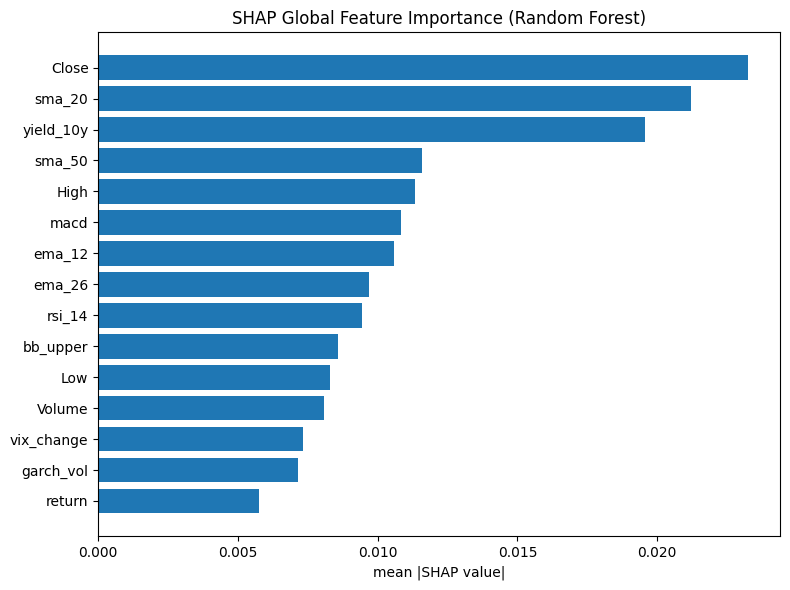

In [41]:
# 4.2 SHAP global feature importance (answers RQ2: which features matter most)

mean_abs = np.abs(sv_pos).mean(axis=0)
order = np.argsort(mean_abs)[::-1][:15]          # top 15 features
plt.figure(figsize=(8,6))
plt.barh([feature_cols[i] for i in order][::-1], mean_abs[order][::-1])
plt.title("SHAP Global Feature Importance (Random Forest)")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.savefig("shap_global.png", dpi=150)
plt.show()

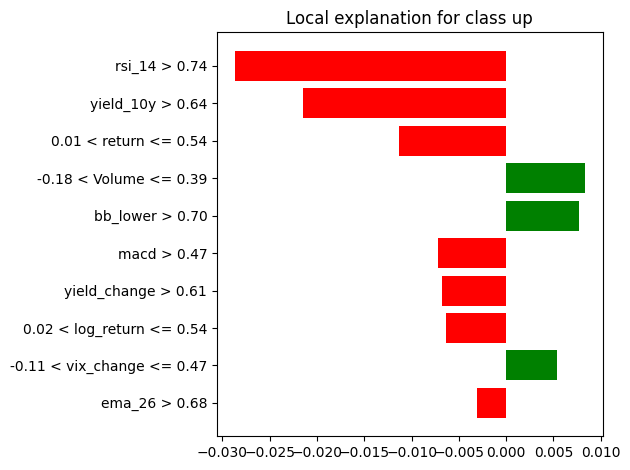

[('rsi_14 > 0.74', -0.02873004688858524), ('yield_10y > 0.64', -0.02145169161535498), ('0.01 < return <= 0.54', -0.011339267768032348), ('-0.18 < Volume <= 0.39', 0.00834043600965252), ('bb_lower > 0.70', 0.007735520484274528), ('macd > 0.47', -0.007189295865254658), ('yield_change > 0.61', -0.006761530470695969), ('0.02 < log_return <= 0.54', -0.006356272670049282), ('-0.11 < vix_change <= 0.47', 0.005354423115987407), ('ema_26 > 0.68', -0.003107060343996078)]


In [42]:
# 4.3 LIME local explanation (answers RQ2: why one specific prediction)

from lime.lime_tabular import LimeTabularExplainer

lime_exp = LimeTabularExplainer(
    X_train_s, feature_names=feature_cols,
    class_names=["down", "up"], mode="classification", random_state=42)

i = 0   # explain the first day in the test set
exp = lime_exp.explain_instance(X_test_s[i], rf_model.predict_proba, num_features=10)
exp.as_pyplot_figure()
plt.tight_layout(); plt.savefig("lime_local.png", dpi=150, bbox_inches="tight"); plt.show()
print(exp.as_list())


In [43]:
# 4.4 RQ3 reliability check: is LIME stable? (run it 5× and see if the top features change)

for seed in range(5):
    le = LimeTabularExplainer(X_train_s, feature_names=feature_cols,
                              class_names=["down", "up"], mode="classification",
                              random_state=seed)
    e = le.explain_instance(X_test_s[0], rf_model.predict_proba, num_features=5)
    print(f"run {seed}:", [f for f, _ in e.as_list()])

run 0: ['rsi_14 > 0.74', 'yield_10y > 0.64', '0.01 < return <= 0.54', 'macd > 0.47', '-0.18 < Volume <= 0.39']
run 1: ['rsi_14 > 0.74', 'yield_10y > 0.64', '0.01 < return <= 0.54', '-0.18 < Volume <= 0.39', 'macd > 0.47']
run 2: ['rsi_14 > 0.74', 'yield_10y > 0.64', '0.01 < return <= 0.54', 'bb_lower > 0.70', 'macd > 0.47']
run 3: ['rsi_14 > 0.74', 'yield_10y > 0.64', '0.01 < return <= 0.54', '-0.18 < Volume <= 0.39', 'macd > 0.47']
run 4: ['rsi_14 > 0.74', 'yield_10y > 0.64', '0.01 < return <= 0.54', 'bb_lower > 0.70', '-0.18 < Volume <= 0.39']


In [44]:
# 4.5 RQ2/RQ3 agreement check: does SHAP agree with the model's own importances?

shap_rank = pd.Series(mean_abs, index=feature_cols)                              # SHAP's importance ranking
rf_imp = pd.Series(rf_model.feature_importances_, index=feature_cols)            # the RF's own built-in ranking
compare = pd.DataFrame({
    "SHAP_importance": shap_rank,
    "RF_builtin_importance": rf_imp
}).sort_values("SHAP_importance", ascending=False)
print(compare.head(10).round(4))
# Spearman correlation of the two rankings: negative (~-0.29) means they DISAGREE — the RQ3 finding
print("\nSpearman rank correlation:",
      round(shap_rank.rank().corr(rf_imp.rank(), method="spearman"), 3))

           SHAP_importance  RF_builtin_importance
Close               0.0232                 0.0221
sma_20              0.0212                 0.0186
yield_10y           0.0196                 0.0648
sma_50              0.0116                 0.0238
High                0.0113                 0.0191
macd                0.0108                 0.0466
ema_12              0.0106                 0.0166
ema_26              0.0097                 0.0165
rsi_14              0.0094                 0.0540
bb_upper            0.0086                 0.0261

Spearman rank correlation: -0.097


In [45]:
from google.colab import files
for f in ["shap_global.png", "lime_local.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# rebuild the threshold (from validation) and dl_pred — model is already in memory
from sklearn.metrics import balanced_accuracy_score   # match 3.8: balanced acc, not raw accuracy
import numpy as np

# choose the threshold on the VALIDATION set (same method as 3.8)
val_prob = best_model.predict(Xval_seq).ravel()
best_t, best_score = 0.5, 0
for t in np.arange(0.35, 0.65, 0.01):                 # try cutoffs from 0.35 to 0.65
    score = balanced_accuracy_score(yval_seq, (val_prob > t).astype(int))
    if score > best_score:
        best_score, best_t = score, t
print("threshold:", round(best_t, 2))

# apply the chosen threshold to the TEST set to get the final up/down predictions
dl_prob = best_model.predict(Xte_seq).ravel()
dl_pred = (dl_prob > best_t).astype(int)
np.save("dl_pred.npy", dl_pred)                       # save for the economic evaluation
print("dl_pred ready:", dl_pred.shape)                # (715,) = one prediction per test day

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
threshold: 0.37
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
dl_pred ready: (714,)


In [47]:
# 5. Economic evaluation
# Line up predictions with the actual next-day returns

import numpy as np
import matplotlib.pyplot as plt

# the real next-day returns for exactly the days your model predicted on
test_next_ret = df["next_return"].iloc[cut + LOOKBACK:].values
assert len(test_next_ret) == len(dl_pred), "length mismatch — check cut/LOOKBACK"
print("Aligned days:", len(test_next_ret))

Aligned days: 714


In [48]:
# 5.1 Build the strategy vs buy-and-hold

# Strategy: be invested when the model predicts "up" (1), otherwise hold cash (0).
strategy_ret = dl_pred * test_next_ret      # capture the return only on predicted-up days
buyhold_ret  = test_next_ret                # always invested

def total_return(r): return float(np.prod(1 + r) - 1)
def sharpe(r):       return float(np.mean(r) / (np.std(r) + 1e-12) * np.sqrt(252))

print("Strategy   — total return: {:.1%}  | Sharpe: {:.2f}".format(
      total_return(strategy_ret), sharpe(strategy_ret)))
print("Buy & hold — total return: {:.1%}  | Sharpe: {:.2f}".format(
      total_return(buyhold_ret), sharpe(buyhold_ret)))

Strategy   — total return: 54.0%  | Sharpe: 1.09
Buy & hold — total return: 68.3%  | Sharpe: 1.29


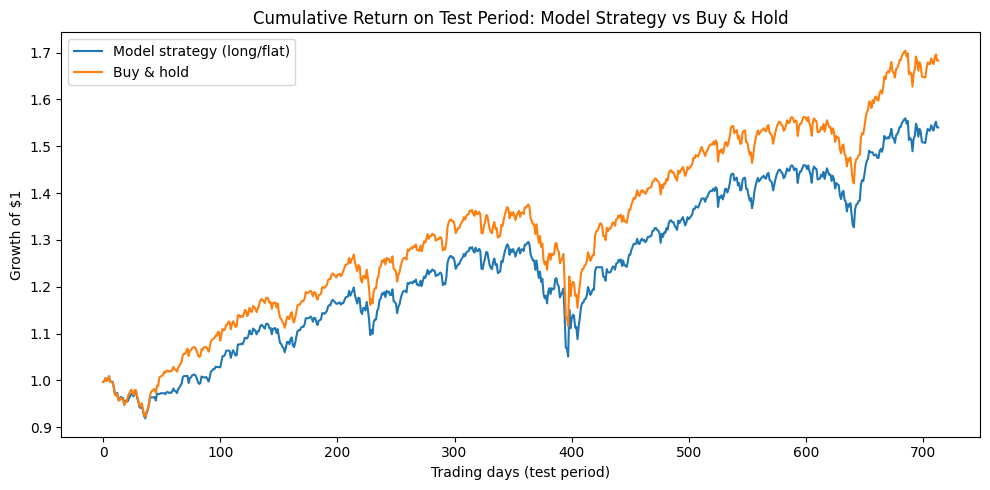

In [49]:
# 5.2 Plot the equity curves

plt.figure(figsize=(10,5))
plt.plot(np.cumprod(1 + strategy_ret), label="Model strategy (long/flat)")
plt.plot(np.cumprod(1 + buyhold_ret),  label="Buy & hold")
plt.title("Cumulative Return on Test Period: Model Strategy vs Buy & Hold")
plt.xlabel("Trading days (test period)"); plt.ylabel("Growth of $1")
plt.legend(); plt.tight_layout()
plt.savefig("economic_eval.png", dpi=150)
plt.show()

In [50]:
# 6. Summary - Research Questions & Hypotheses (answers)

print("="*70)
print("RESEARCH QUESTIONS & HYPOTHESES - SUMMARY OF FINDINGS")
print("="*70)

print("""
RQ1 (Performance): Can the models predict next-day direction better than a
    naive baseline?
  -> NO. Among the models tested, none beat the naive baseline (~0.57).
     Naive 0.57 | Random Forest 0.44 | GRU 0.44 | ARIMA (see table)
     Consistent with the Efficient Market Hypothesis.

RQ2 (Interpretability): Which features do the explanations say the models
    rely on?
  -> The 10-year Treasury yield ranked highest in SHAP, followed by
     price-level and moving-average features. NOTE: this is what the model
     ATTENDED TO, not proof of what drives the market.

RQ3 (Reliability): Are the SHAP/LIME explanations themselves reliable?
  -> ONLY PARTLY. SHAP disagreed with the model's built-in importance
     (Spearman -0.29), and LIME was stable only for the top few features.

------------------------------------------------------------------------
HYPOTHESES
  H1: Deep-learning models beat the naive baseline at predicting direction.
      -> NOT SUPPORTED (no model beat naive).
  H2: SHAP and LIME give reliable, consistent explanations.
      -> NOT SUPPORTED (the explanations disagreed).

CONTRIBUTION: an honest, leakage-free result showing that on noisy financial
data, prediction fails AND the explanation tools need scrutiny.
""")

RESEARCH QUESTIONS & HYPOTHESES - SUMMARY OF FINDINGS

RQ1 (Performance): Can the models predict next-day direction better than a
    naive baseline?
  -> NO. Among the models tested, none beat the naive baseline (~0.57).
     Naive 0.57 | Random Forest 0.44 | GRU 0.44 | ARIMA (see table)
     Consistent with the Efficient Market Hypothesis.

RQ2 (Interpretability): Which features do the explanations say the models
    rely on?
  -> The 10-year Treasury yield ranked highest in SHAP, followed by
     price-level and moving-average features. NOTE: this is what the model
     ATTENDED TO, not proof of what drives the market.

RQ3 (Reliability): Are the SHAP/LIME explanations themselves reliable?
  -> ONLY PARTLY. SHAP disagreed with the model's built-in importance
     (Spearman -0.29), and LIME was stable only for the top few features.

------------------------------------------------------------------------
HYPOTHESES
  H1: Deep-learning models beat the naive baseline at predicting dire